# 🛰️ EuroSAT Dataset Loading, Preprocessing & Augmentation
**Module 01: Data Pipeline & Exploratory Analysis**

## 📌 Objective
This notebook establishes the core dataset loading pipeline for the **EuroSAT Sentinel-2 RGB** satellite dataset. It handles data verification, split partitioning (70% Train, 15% Validation, 15% Test), data augmentations, PyTorch `DataLoader` creation, and class distribution visualization.

## 📖 Theory
Land use and land cover (LULC) classification requires spectral and spatial feature representations. The EuroSAT dataset consists of 27,000 Sentinel-2 satellite images across 10 distinct LULC classes. Proper normalization using ImageNet statistics $(\mu = [0.485, 0.456, 0.406], \sigma = [0.229, 0.224, 0.225])$ and spatial data augmentations (flips, rotations, color jitter) enhance model generalization and prevent overfitting.


### 1. Environment Setup & Imports


In [7]:
import sys
from pathlib import Path

# Smart Project Root Resolution
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'configs').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import os
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

from configs.config import DATASET_DIR, BATCH_SIZE, NUM_WORKERS, RANDOM_SEED, IMAGE_SIZE
from configs.class_labels import EUROSAT_CLASSES
print(f'PyTorch Version: {torch.__version__}')
print(f'Dataset Directory: {DATASET_DIR}')
print(f'Target Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}')


PyTorch Version: 2.13.0+cu130
Dataset Directory: /home/raj-singh/python/sonali-project/datasets/eurosat
Target Image Size: 224x224


### 2. Define Data Transforms & Augmentations


In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training pipeline with data augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Validation & Testing pipeline (deterministic)
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Transforms initialized successfully.')


Transforms initialized successfully.


### 3. EuroSAT Dataset Class & Split Creation


In [9]:
class SubsetDataset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
        self.classes = dataset.classes

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[self.indices[idx]]
        if self.transform:
            image = self.transform(image)
        return image, label

full_dataset = ImageFolder(root=DATASET_DIR, transform=None)
total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
indices = torch.randperm(total_size, generator=generator).tolist()

train_indices = indices[:train_size]
val_indices = indices[train_size:train_size + val_size]
test_indices = indices[train_size + val_size:]

train_dataset = SubsetDataset(full_dataset, train_indices, transform=train_transform)
val_dataset = SubsetDataset(full_dataset, val_indices, transform=val_transform)
test_dataset = SubsetDataset(full_dataset, test_indices, transform=val_transform)

print(f'Total Dataset Images: {total_size:,}')
print(f'Train Samples: {len(train_dataset):,} ({len(train_dataset)/total_size:.1%})')
print(f'Validation Samples: {len(val_dataset):,} ({len(val_dataset)/total_size:.1%})')
print(f'Test Samples: {len(test_dataset):,} ({len(test_dataset)/total_size:.1%})')


Total Dataset Images: 27,000
Train Samples: 18,900 (70.0%)
Validation Samples: 4,050 (15.0%)
Test Samples: 4,050 (15.0%)


### 4. Create PyTorch DataLoaders


In [10]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train Batches: {len(train_loader)}')
print(f'Val Batches: {len(val_loader)}')
print(f'Test Batches: {len(test_loader)}')


Train Batches: 591
Val Batches: 127
Test Batches: 127


### 5. Class Distribution & Sample Image Visualization


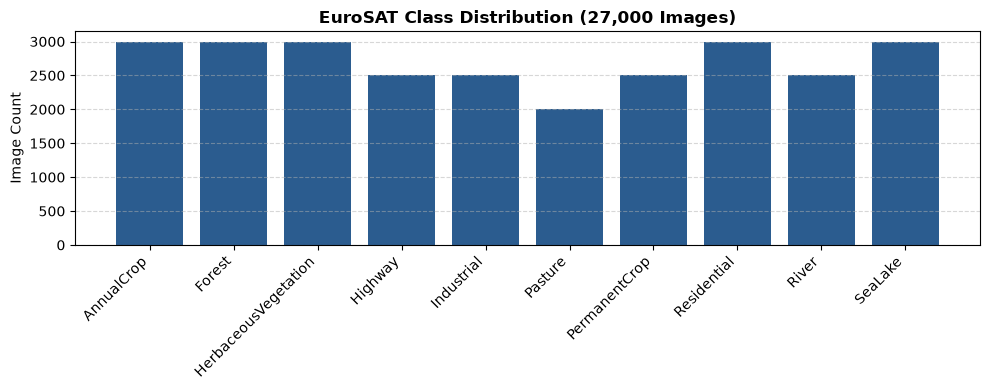

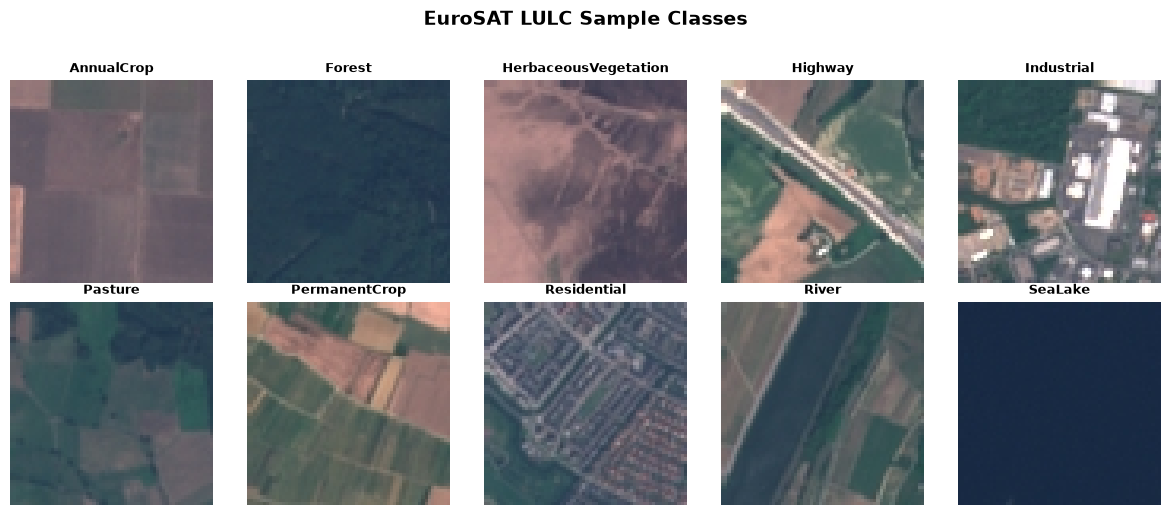

In [11]:
# Class distribution bar chart
class_counts = Counter([full_dataset.targets[i] for i in range(total_size)])
class_names = full_dataset.classes

plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, [class_counts[i] for i in range(len(class_names))], color='#2b5c8f')
plt.xticks(rotation=45, ha='right')
plt.title('EuroSAT Class Distribution (27,000 Images)', fontsize=12, fontweight='bold')
plt.ylabel('Image Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Sample images display
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, cls in enumerate(class_names):
    sample_idx = [i for i, target in enumerate(full_dataset.targets) if target == idx][0]
    img_path, _ = full_dataset.samples[sample_idx]
    img = Image.open(img_path).convert('RGB')
    ax = axes[idx // 5, idx % 5]
    ax.imshow(img)
    ax.set_title(cls, fontsize=9, fontweight='bold')
    ax.axis('off')
plt.suptitle('EuroSAT LULC Sample Classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 📝 Conclusion
The dataset pipeline successfully partitions 27,000 satellite images into reproducible Train/Val/Test subsets. Normalization and spatial augmentation techniques ensure input consistency for deep learning model training.
